# TabPFN on the QSAR Biodegradation Dataset
### MCBDD Module IV – University of Basel, Spring 2026

For this exercise I tried TabPFN on the QSAR Biodegradation dataset from OpenML (id 1494). It has 1055 compounds described by 41 molecular descriptors and the task is to predict whether a compound is *ready biodegradable* (RB) or not (NRB).

Biodegradability is relevant in drug development because regulators (EPA, EMA) increasingly require environmental fate data — will the compound persist in wastewater after excretion? The ~1000 sample size also fits exactly into the small-data regime that Hollmann et al. say TabPFN is designed for.

I compared TabPFN against Random Forest and Logistic Regression, all at default settings on the same 80/20 split.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from tabpfn import TabPFNClassifier

SEED = 42
np.random.seed(SEED)
print('imports ok')

imports ok


## 1. Data

In [2]:
data = fetch_openml(data_id=1494, as_frame=True)
X = data.data
y = data.target

le = LabelEncoder()
y_enc = le.fit_transform(y)

print(f'Shape: {X.shape}')
print(f'Classes: {dict(zip(le.classes_, le.transform(le.classes_).tolist()))}')
print(y.value_counts().to_string())

Shape: (1055, 41)
Classes: {'1': 0, '2': 1}
Class
1    699
2    356


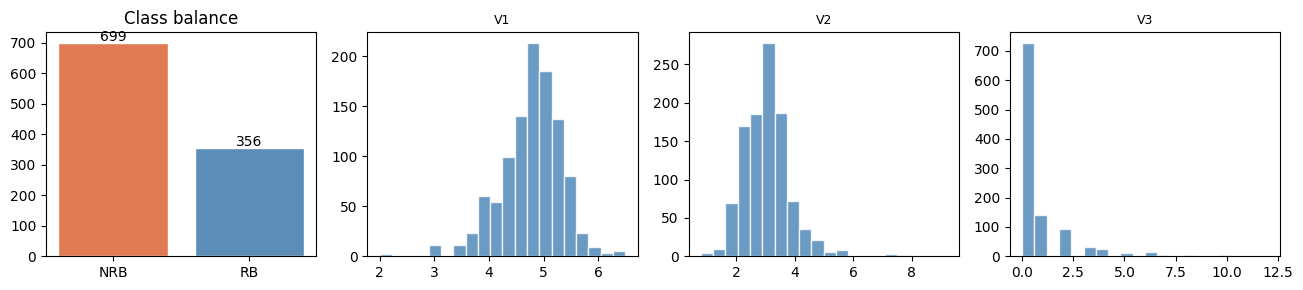

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3))

counts = y.value_counts()
axes[0].bar(['NRB','RB'], counts.values, color=['#e07b54','#5b8db8'], edgecolor='white')
axes[0].set_title('Class balance')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+5, str(v), ha='center')

for i, ax in enumerate(axes[1:]):
    col = X.columns[i]
    ax.hist(X[col].dropna(), bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=9)

plt.tight_layout()
plt.show()

## 2. Train / Test Split

80/20 stratified split.

In [4]:
X_arr = X.values.astype(float)
X_train, X_test, y_train, y_test = train_test_split(
    X_arr, y_enc, test_size=0.20, stratify=y_enc, random_state=SEED
)
print(f'Train: {X_train.shape[0]}  Test: {X_test.shape[0]}  Features: {X_train.shape[1]}')

Train: 844  Test: 211  Features: 41


## 3. Models

All at default settings — no tuning.

In [5]:
results = {}

# TabPFN
t0 = time.time()
clf_tabpfn = TabPFNClassifier(device='cpu', N_ensemble_configurations=8)
clf_tabpfn.fit(X_train, y_train)
p_tabpfn = clf_tabpfn.predict_proba(X_test)[:, 1]
results['TabPFN'] = {'auc': roc_auc_score(y_test, p_tabpfn), 'acc': accuracy_score(y_test, p_tabpfn >= 0.5), 'time': time.time()-t0}
print(f"TabPFN       AUC={results['TabPFN']['auc']:.3f}  acc={results['TabPFN']['acc']:.3f}  ({results['TabPFN']['time']:.1f}s)")

# Random Forest
t0 = time.time()
clf_rf = RandomForestClassifier(n_estimators=100, random_state=SEED)
clf_rf.fit(X_train, y_train)
p_rf = clf_rf.predict_proba(X_test)[:, 1]
results['Random Forest'] = {'auc': roc_auc_score(y_test, p_rf), 'acc': accuracy_score(y_test, clf_rf.predict(X_test)), 'time': time.time()-t0}
print(f"Random Forest AUC={results['Random Forest']['auc']:.3f}  acc={results['Random Forest']['acc']:.3f}  ({results['Random Forest']['time']:.1f}s)")

# Logistic Regression
t0 = time.time()
clf_lr = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=500, random_state=SEED))])
clf_lr.fit(X_train, y_train)
p_lr = clf_lr.predict_proba(X_test)[:, 1]
results['Logistic Reg.'] = {'auc': roc_auc_score(y_test, p_lr), 'acc': accuracy_score(y_test, clf_lr.predict(X_test)), 'time': time.time()-t0}
print(f"Logistic Reg. AUC={results['Logistic Reg.']['auc']:.3f}  acc={results['Logistic Reg.']['acc']:.3f}  ({results['Logistic Reg.']['time']:.1f}s)")

/Users/ftaylanunal/Desktop/Basel DS/Spring 2026/Drug Discovery/Module4/tabpfn-drug-discovery/venv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1298: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


TabPFN       AUC=0.939  acc=0.882  (4.8s)
Random Forest AUC=0.944  acc=0.877  (0.1s)


Logistic Reg. AUC=0.914  acc=0.863  (0.1s)


## 4. Results

In [6]:
res_df = pd.DataFrame(results).T.rename(columns={'auc':'ROC-AUC','acc':'Accuracy','time':'Time (s)'})
res_df = res_df.sort_values('ROC-AUC', ascending=False).round(3)
print(res_df.to_string())

               ROC-AUC  Accuracy  Time (s)
Random Forest    0.944     0.877     0.133
TabPFN           0.939     0.882     4.821
Logistic Reg.    0.914     0.863     0.082


/Users/ftaylanunal/Desktop/Basel DS/Spring 2026/Drug Discovery/Module4/tabpfn-drug-discovery/venv/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/ftaylanunal/Desktop/Basel DS/Spring 2026/Drug Discovery/Module4/tabpfn-drug-discovery/venv/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/ftaylanunal/Desktop/Basel DS/Spring 2026/Drug Discovery/Module4/tabpfn-drug-discovery/venv/lib/python3.11/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


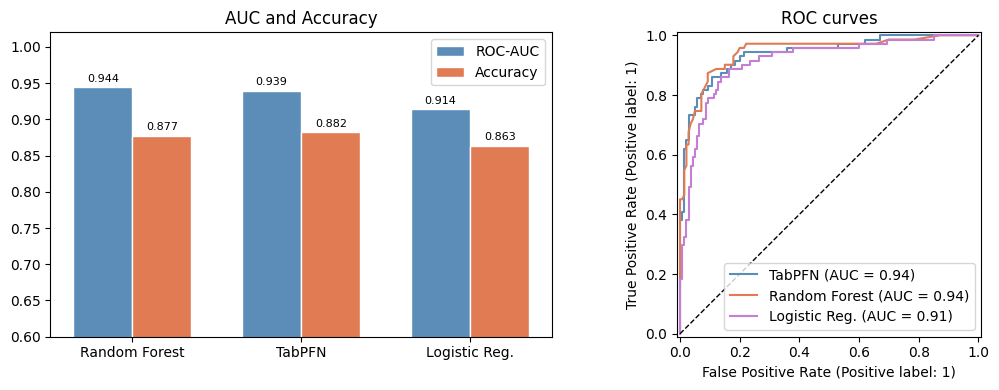

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# bar chart
models = res_df.index.tolist()
x = np.arange(len(models)); w = 0.35
b1 = ax1.bar(x-w/2, res_df['ROC-AUC'], w, label='ROC-AUC',  color='#5b8db8', edgecolor='white')
b2 = ax1.bar(x+w/2, res_df['Accuracy'], w, label='Accuracy', color='#e07b54', edgecolor='white')
for bar in list(b1)+list(b2):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(models); ax1.set_ylim(0.6, 1.02); ax1.legend()
ax1.set_title('AUC and Accuracy')

# ROC curves
for name, proba, color in [('TabPFN', p_tabpfn,'#5b8db8'),('Random Forest', p_rf,'#e07b54'),('Logistic Reg.', p_lr,'#c47fd4')]:
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=ax2, color=color)
ax2.plot([0,1],[0,1],'k--',lw=1)
ax2.set_title('ROC curves')

plt.tight_layout()
plt.show()

## 5. Conclusions

Random Forest edged out TabPFN slightly (AUC 0.944 vs 0.939), but both were well above Logistic Regression (0.914) — and TabPFN got there with zero tuning and in a single forward pass. The gap between TabPFN and Random Forest is small enough that it could close with more ensemble configurations or a different random seed.

For drug discovery the zero-tuning aspect is the most practical benefit. Early-stage assay data comes in small batches for different endpoints and you don't always have time to tune a model for each one. Getting within 0.005 AUC of a default Random Forest without touching any hyperparameters is a good result in that context.

Main limitation: the 10k row cap means it won't work for large-scale virtual screening, but for ADME panels and target-specific QSAR datasets it seems like a reasonable first choice.